In [1]:
%load_ext autoreload
%autoreload 2

%gui qt

In [2]:
import os
import sys
import importlib
gui_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite/gui_source")
josh_source_dir = os.path.expanduser("~/Documents/talmolab/repos/lucid_lite")

# add folders to Python's system path so it can find local imports
if gui_source_dir not in sys.path:
    sys.path.insert(0, gui_source_dir)
    sys.path.insert(0, josh_source_dir)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import numpy as np
import pandas as pd
import sleap_io as sio

from PySide6.QtGui import QImage


from lucid_lite.gui_source import main
from lucid_lite.gui_source import colors

from josh_source import epipolar
from josh_source import geometry

In [42]:
app, window = main.main(
    [
        "main.py",                                                          
        "/Users/joshuapark/Documents/talmolab/lucid_folders/10072022145420_small"
    ]
)
# define globals
session = window.session

SKEL = session.skeleton
TRACK_COLOR_MAP = {track: colors.get_track_color(n) for n, track in enumerate(session.tracks)}
CAMERAS = {camera.name: camera for camera in session.cameras}

NODE_NAMES = [
    "Nose",
    "Ear_R",
    "Ear_L",
    "TTI",
    "TailTip",
    "Head",
    "Trunk",
    "Tail_0",
    "Tail_1",
    "Tail_2",
    "Shoulder_left",
    "Shoulder_right",
    "Haunch_left",
    "Haunch_right",
    "Neck"
]

def frame_df(frame_idx = None):
    if frame_idx is None:
        fg = session.frame_group(window._current_frame)
    else:
        fg = session.frame_group(frame_idx)
    assert fg.frame_idx == frame_idx
    rows = []
    for cam, insts in fg.instances.items():
        for inst in insts:
            rows.append({
                'cam': cam,
                'points': inst.points,
                'track_idx': inst.track_idx,
                "track": (session.tracks[inst.track_idx]
                        if inst.track_idx is not None else None),
                "identity_id": session.get_identity_id_for_track(
                    window._current_frame, cam, inst.track_idx),
                "type": inst.type,
                "score": inst.score,
                "n_visible": sum(p is not None for p in inst.points),
            })
    return pd.DataFrame(rows), fg


Error reconstructing FrameGroup: {'frame_idx': 0, 'instance_groups': [{'identity_idx': 2, 'points': [[48.274210531915045, -32.83364109623553, 1151.7922172896963], [83.07571957116458, -20.36973935475563, 1122.5767561306118], [48.60493063151847, -9.609941024846487, 1114.0203336967766], [118.1938555894995, 62.41805188430688, 1127.1038565057063], None, [63.183150565422935, -19.64047653555298, 1119.002217769748], [87.95001857752469, 28.003282991643157, 1113.8276833747993], [130.5468355849119, 98.39776894094688, 1127.8148572723746], [134.4872571635714, 120.10234736402975, 1114.5880371853975], [123.79095702963008, 147.5698802676192, 1119.798072697085], [45.2962926550307, -1.5282608506390873, 1138.1616990219975], [77.91839844248832, -15.904808598982878, 1147.9461334695127], [78.08237333977365, 56.15708812863012, 1134.041451388676], [110.51038828679032, 21.380386282260435, 1140.5983908960961], [66.71531746227073, -10.19857028548516, 1115.945911835526]], 'instances': {'0': {'Nose': [893.38220214

# Visualize Some frames

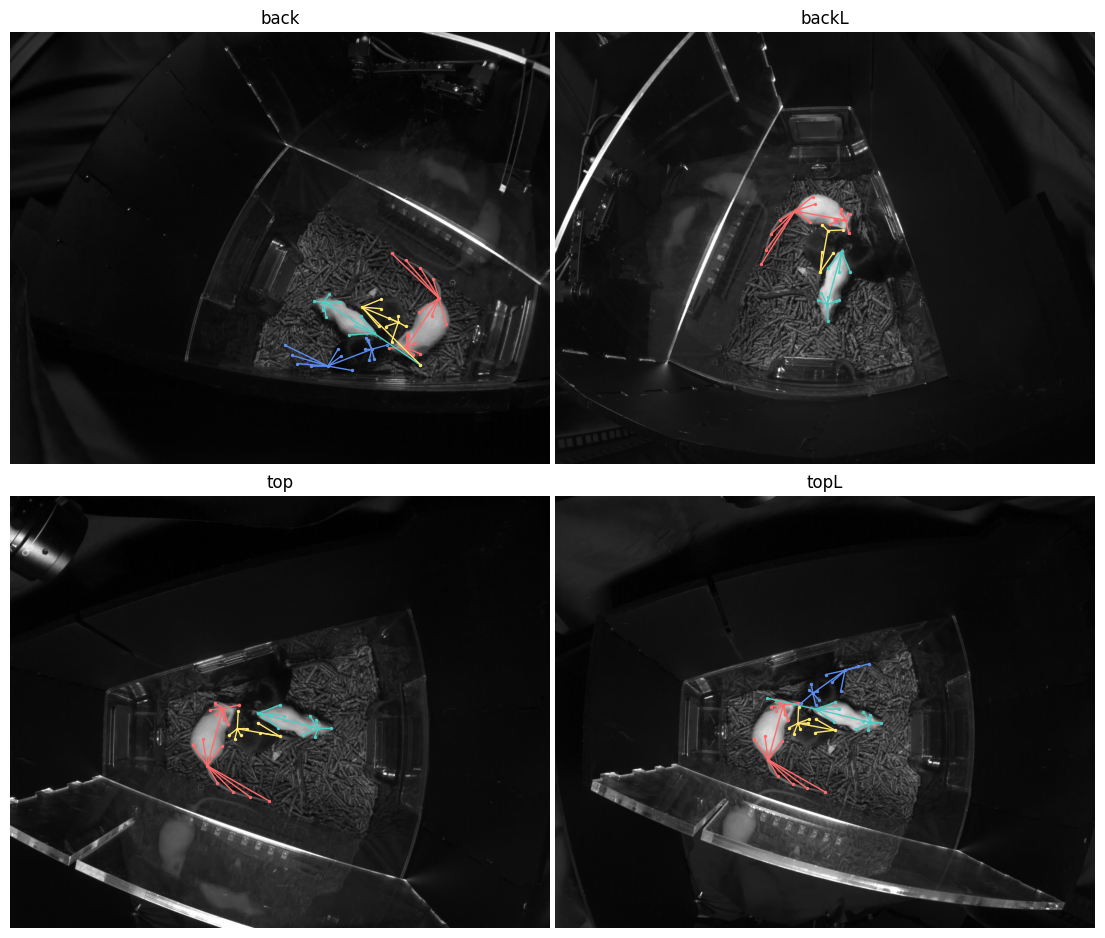

In [6]:
df = frame_df()
epipolar.display_cams(
    window,
    ['back', 'backL', 'top', 'topL'],
    df,
    SKEL,
    TRACK_COLOR_MAP,
    (2, 2))

In [44]:
fg.frame_idx

87

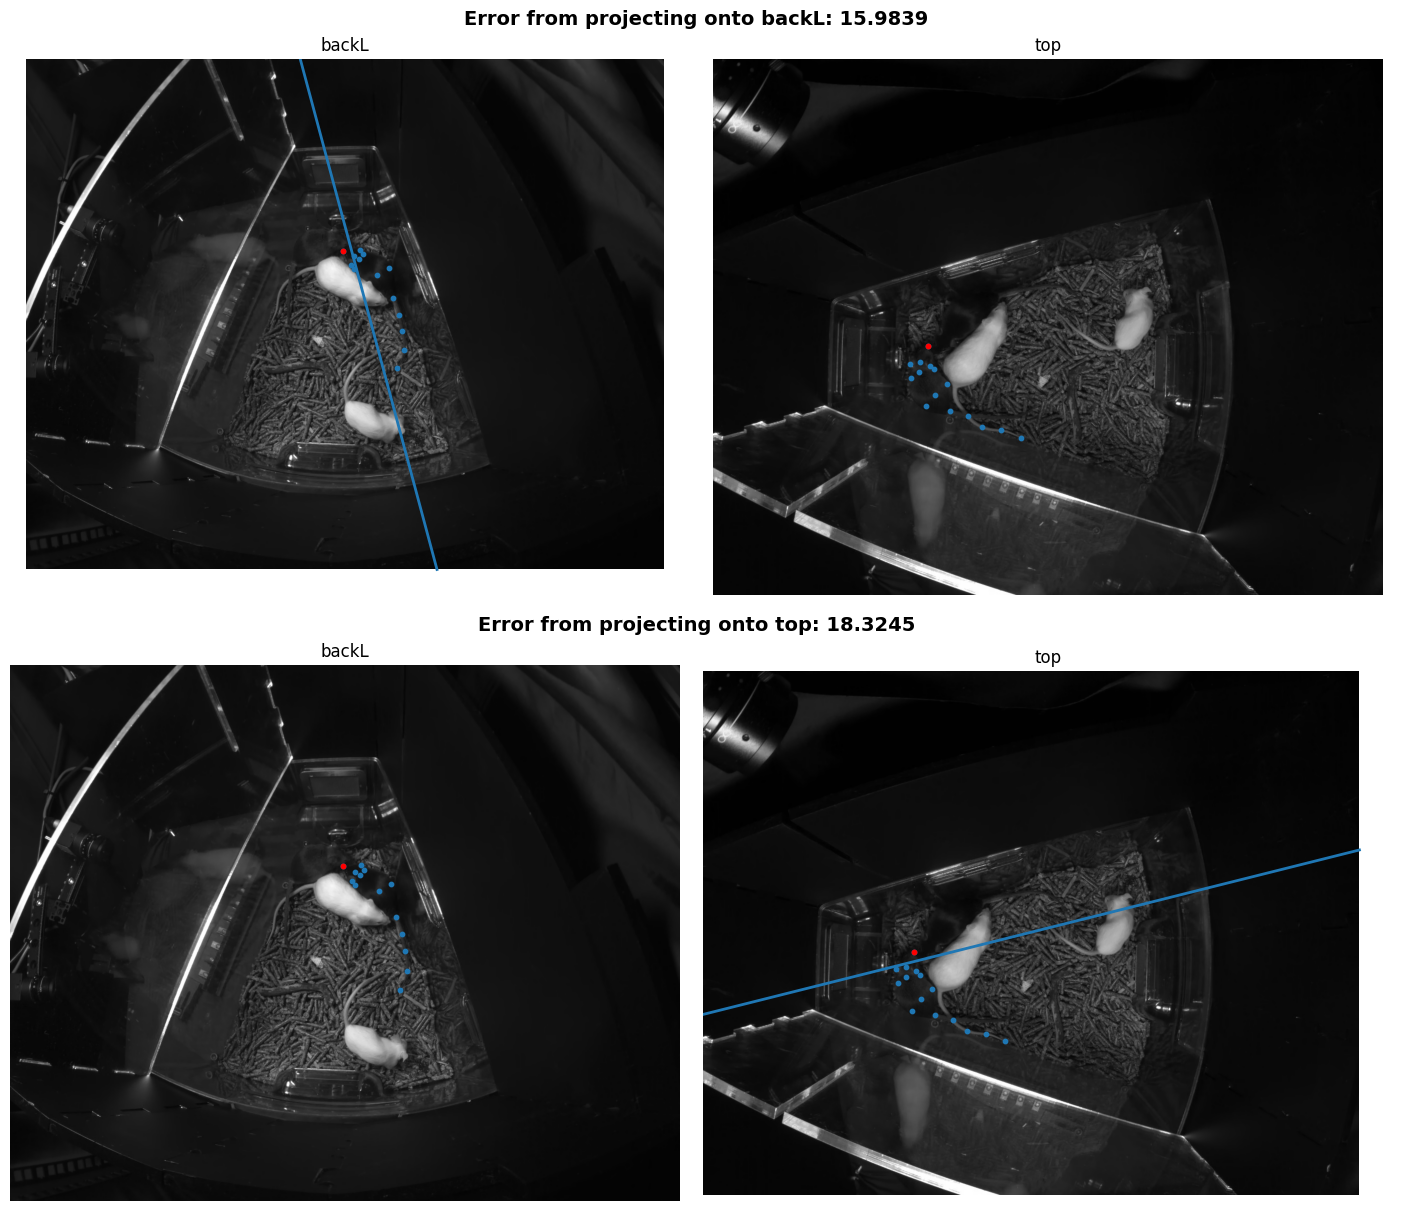

In [56]:
importlib.reload(epipolar)

df, fg = frame_df(frame_idx = 87)

epipolar.draw_epline_single_point(window, fg, CAMERAS, ['backL', 'top'], df, node_idx=0, track_idx=2)
print()

In [ ]:
# df.query('cam == "backL" and track_idx ==2').points.iloc[0]


,cam,points,track_idx,track,identity_id,type,score,n_visible
4,backL,"[(723.994384765625, 488.0931091308594), (666.3...",0,global_0,None,predicted,0.961358,15
5,backL,"[(754.9613037109375, 720.0484619140625), (754....",1,global_1,None,predicted,0.960108,15
6,backL,"[(636.1373291015625, 384.04083251953125), (670...",3,global_3,None,predicted,0.801342,14


lines1 shape: (3, 15)
lines2 shape: (3, 15)
lines1 shape: (3, 15)
lines2 shape: (3, 15)
9.113592945171535
8.516938457189285


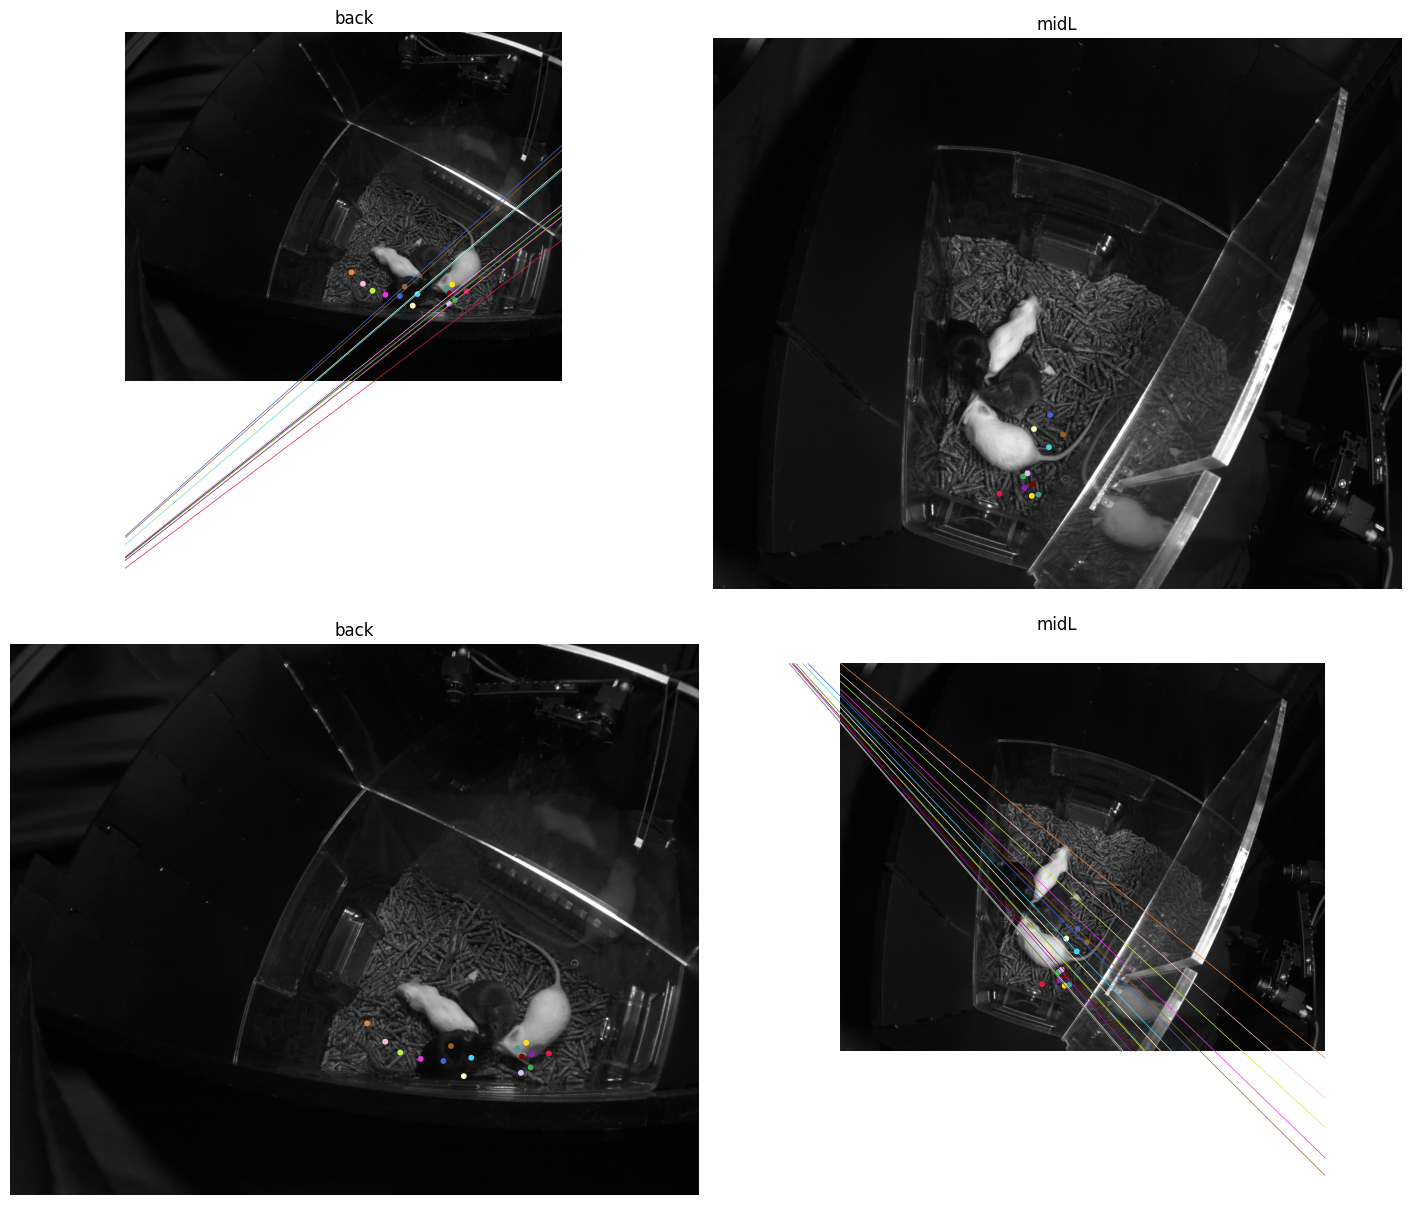

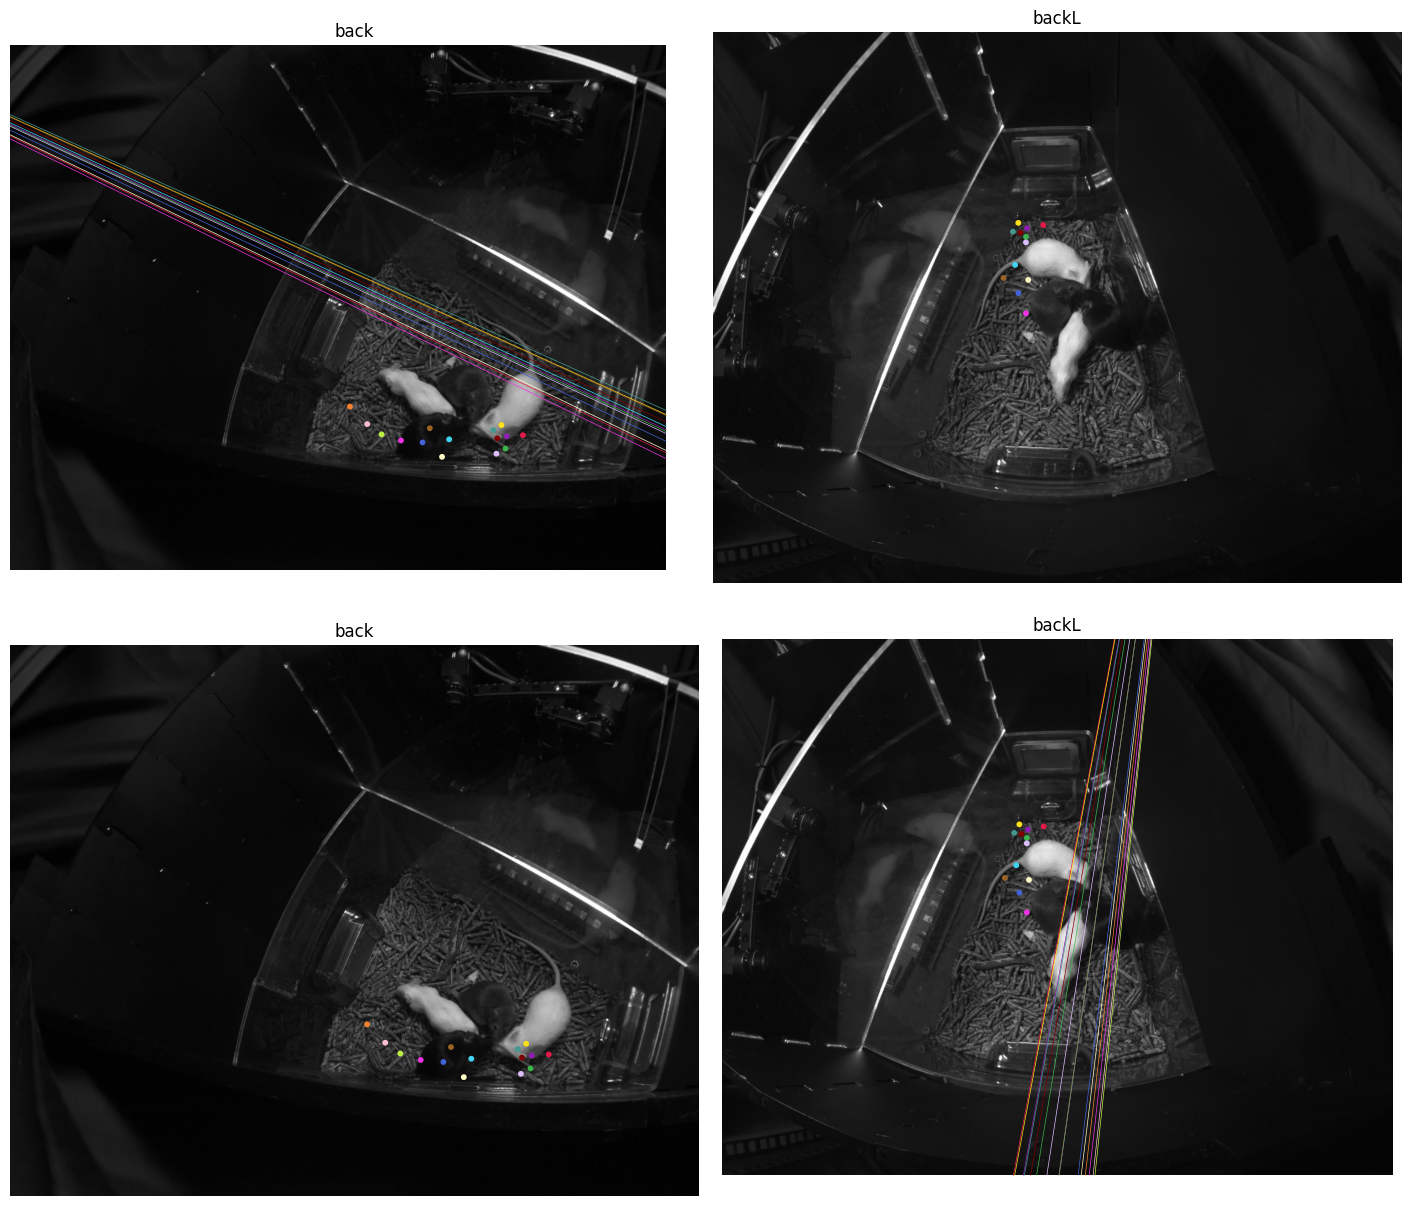

In [50]:
importlib.reload(epipolar)

df = frame_df(frame_idx = 67)
error = epipolar.draw_eplines_whole_instance(window, CAMERAS, ['back', 'midL'], df, track_idx=2)

# print(f'sum image 1 error: {np.nansum(np.abs(error[0])):.3f}')
# print(f'sum image 2 error: {np.nansum(np.abs(error[1])):.3f}')

epipolar.draw_eplines_whole_instance(window, CAMERAS, ['back', 'backL'], df, track_idx=2)
print(np.nanmean(error[0]))
print(np.nanmean(error[1]))
# F = geometry.calc_fundamental_matrix(CAMERAS['back'], CAMERAS['backL'])
# error = geometry.calc_epipolar_score(pt1, pt2, F)

# error

# Pair-Wise Matching

In [9]:
df = frame_df()